In [ ]:
import numpy as np
from numpyro import distributions as dist
import numpyro
import polars as pl
import jax.numpy as jnp
from jax import random
import jax
from pathlib import Path
import datetime as dt
from matplotlib import pyplot as plt
import xarray as xr

import arviz as az

numpyro.set_host_device_count(4)

data_dir = Path("./data")
df = (
    pl.read_csv(data_dir / "cleaned_games.csv")
    .with_columns(pl.col("Datetime").str.strptime(pl.Datetime).alias("Datetime"))
    .filter(
        pl.col("Datetime") >= dt.datetime(2025, 10, 1),
        pl.col("Arizona Coyotes") == 0,
    )
    .drop("Arizona Coyotes")
)

# current season games only

teams = (
    pl.read_csv(data_dir / "teams.txt", has_header=False)
    .filter(pl.col("column_1") != "Arizona Coyotes")
    .to_series()
    .to_list()
)

In [3]:
day_of_season = (df["Datetime"] - df["Datetime"].min()).dt.total_days().to_jax()
day_of_season = day_of_season - day_of_season.mean()
team_matchups = df[teams].to_jax()
home_wins = df["home_win"].to_jax()
home_goals = df["Home_G"].to_jax()
away_goals = df["Away_G"].to_jax()
overtimes = df["OT"].to_jax()


home_win_ot = home_wins * overtimes
away_win_ot = (1 - home_wins) * overtimes

home_g_reg = jnp.where(home_win_ot == 1, home_goals - 1, home_goals)
away_g_reg = jnp.where(away_win_ot == 1, away_goals - 1, away_goals)

train_shape = int(0.8 * len(df))

(
    train_matchups,
    test_matchups,
    train_home_wins,
    test_home_wins,
    train_away_goals,
    test_away_goals,
    train_home_goals,
    test_home_goals,
    train_overtimes,
    test_overtimes,
) = (
    team_matchups[:train_shape],
    team_matchups[train_shape:],
    home_wins[:train_shape],
    home_wins[train_shape:],
    away_g_reg[:train_shape],
    away_g_reg[train_shape:],
    home_g_reg[:train_shape],
    home_g_reg[train_shape:],
    overtimes[:train_shape],
    overtimes[train_shape:],
)

In [4]:
def log_bessel_fn(x, n, max_terms=30):
    def log_term(k):
        return (
            (2 * k + n) * jnp.log(x / 2)
            - jax.scipy.special.gammaln(k + n + 1)
            - jax.scipy.special.gammaln(k + 1)
        )

    bessel_approx = jax.scipy.special.logsumexp(
        jax.vmap(log_term)(jnp.arange(max_terms)), axis=0
    )
    return bessel_approx


class Skellam(dist.Distribution):
    arg_constraints = {
        "mu1": dist.constraints.positive,
        "mu2": dist.constraints.positive,
    }
    support = dist.constraints.integer_interval(-jnp.inf, jnp.inf)

    def __init__(self, mu1, mu2, validate_args=None):
        self.mu1 = mu1
        self.mu2 = mu2
        super().__init__(batch_shape=jnp.shape(mu1), validate_args=validate_args)

    def log_prob(self, k):
        log_pmf = (
            -(self.mu1 + self.mu2)
            + k * jnp.log(self.mu1 / self.mu2) / 2
            + log_bessel_fn(2 * jnp.sqrt(self.mu1 * self.mu2), jnp.abs(k))
        )
        return log_pmf

    def sample(self, key, sample_shape=()):
        key1, key2 = random.split(key)
        return dist.Poisson(self.mu1).sample(key1, sample_shape) - dist.Poisson(
            self.mu2
        ).sample(key2, sample_shape)

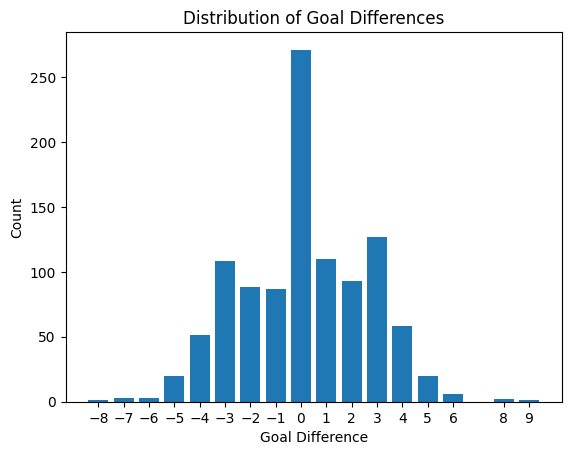

In [5]:
vals, counts = jnp.unique_counts(train_home_goals - train_away_goals)
fig, ax = plt.subplots()
ax.bar(vals, counts)
ax.set_xlabel("Goal Difference")
ax.set_ylabel("Count")
ax.set_xticks(vals)
ax.set_title("Distribution of Goal Differences")
plt.show()

In [6]:
# @numpyro.handlers.reparam(config={"team_home_advantage": numpyro.infer.reparam.LocScaleReparam()})
def model(matchups, home_g=None, away_g=None, is_ot=None, home_win=None):
    sigma_offense = numpyro.sample("sigma_offense", dist.InverseGamma(1, 1))
    sigma_defense = numpyro.sample("sigma_defense", dist.InverseGamma(1, 1))

    home_advantage = numpyro.sample("home_advantage", dist.Normal(0, 0.1))
    base_intercept = numpyro.sample("base_intercept", dist.Normal(0, 1))
    sigma_home_team = numpyro.sample("sigma_home_team", dist.InverseGamma(1, 1))
    # Non-centered: sample on unit scale, multiply by sigma outside
    with numpyro.plate("teams", size=matchups.shape[1]):
        offense_raw = numpyro.sample("offense_raw", dist.Normal(0, 1))
        defense_raw = numpyro.sample("defense_raw", dist.Normal(0, 1))
        # team_home_advantage = numpyro.sample("team_home_advantage", dist.Normal(home_advantage, sigma_home_team))

    # Scale + sum-to-zero: kills the add-c-to-both degeneracy
    log_offense = sigma_offense * (offense_raw - offense_raw.mean())
    log_defense = sigma_defense * (defense_raw - defense_raw.mean())
    numpyro.deterministic("offense_goals", jnp.exp(log_offense))
    numpyro.deterministic("defense_goals", jnp.exp(log_defense))

    home_team_idx = jnp.argmax(matchups, axis=1)
    away_team_idx = jnp.argmin(matchups, axis=1)

    lambda_home = numpyro.deterministic(
        "lambda_home",
        jnp.exp(
            base_intercept
            + log_offense[home_team_idx]
            - log_defense[away_team_idx]
            # + team_home_advantage[home_team_idx]
            + home_advantage
        ),
    )
    lambda_away = numpyro.deterministic(
        "lambda_away",
        jnp.exp(
            base_intercept + log_offense[away_team_idx] - log_defense[home_team_idx]
        ),
    )
    ot_mask = (home_g == away_g) if is_ot is None else is_ot == 1
    ot_win_prob = numpyro.deterministic(
        "win_prob", lambda_home / (lambda_home + lambda_away)
    )
    skellam_pmf = Skellam(lambda_home, lambda_away)

    prob_1_or_greater = jnp.exp(
        jax.vmap(skellam_pmf.log_prob, in_axes=(0))(jnp.arange(1, 12))
    ).sum(axis=0)
    prob_0 = jnp.exp(skellam_pmf.log_prob(0)) * ot_win_prob
    prob_home_win = numpyro.deterministic("prob_home_win", prob_1_or_greater + prob_0)

    with numpyro.plate("obs", size=matchups.shape[0]):
        home_g = numpyro.sample("home_g_raw", dist.Poisson(lambda_home), obs=home_g)
        away_g = numpyro.sample("away_g_raw", dist.Poisson(lambda_away), obs=away_g)

        home_ot_wins = numpyro.sample(
            "home_ot_wins", dist.Bernoulli(ot_win_prob), obs=home_win, obs_mask=ot_mask
        )

        home_g_final = numpyro.deterministic(
            "home_g", home_g + jnp.where(ot_mask, home_ot_wins.astype(int), 0)
        )
        away_g_final = numpyro.deterministic(
            "away_g", away_g + jnp.where(ot_mask, 1 - home_ot_wins.astype(int), 0)
        )

In [33]:
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(
    kernel,
    num_warmup=2000,
    num_samples=1000,
    num_chains=4,
)

mcmc.run(
    random.key(98102938376),
    matchups=train_matchups,
    home_g=train_home_goals,
    away_g=train_away_goals,
    is_ot=train_overtimes,
    home_win=train_home_wins,
)

jax.effects_barrier()

/Users/mmcanear/Projects/hockey/.venv/lib/python3.14/site-packages/jax/_src/linear_util.py:212: FutureWarning: Some algorithms will automatically enumerate the discrete latent site home_ot_wins_unobserved of your model. In the future, enumerated sites need to be marked with `infer={'enumerate': 'parallel'}`.
  return self.f_transformed(*args, **kwargs)
Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]



Running chain 0:   5%|▌         | 150/3000 [00:02<00:13, 203.98it/s]


Running chain 0:  10%|█         | 300/3000 [00:02<00:06, 390.83it/s]


Running chain 0:  15%|█▌        | 450/3000 [00:03<00:04, 541.73it/s]


Running chain 0:  20%|██        | 600/3000 [00:03<00:03, 696.85it/s]


Running chain 0:  25%|██▌       | 750/3000 [00:03<00:02, 837.85it/s]


Running chain 0:  30%|███       | 900/3000 [00:03<00:02, 947.90it/s]


Running chain 0:  35%|███▌      | 1050/3000 [00:03<00:01, 1030.65it/s]


Running chain 0:  40%|███

In [34]:
trace = az.from_numpyro(
    mcmc,
    coords={"team": teams},
    dims={
        "offense_goals": ["team"],
        "defense_goals": ["team"],
    },
)

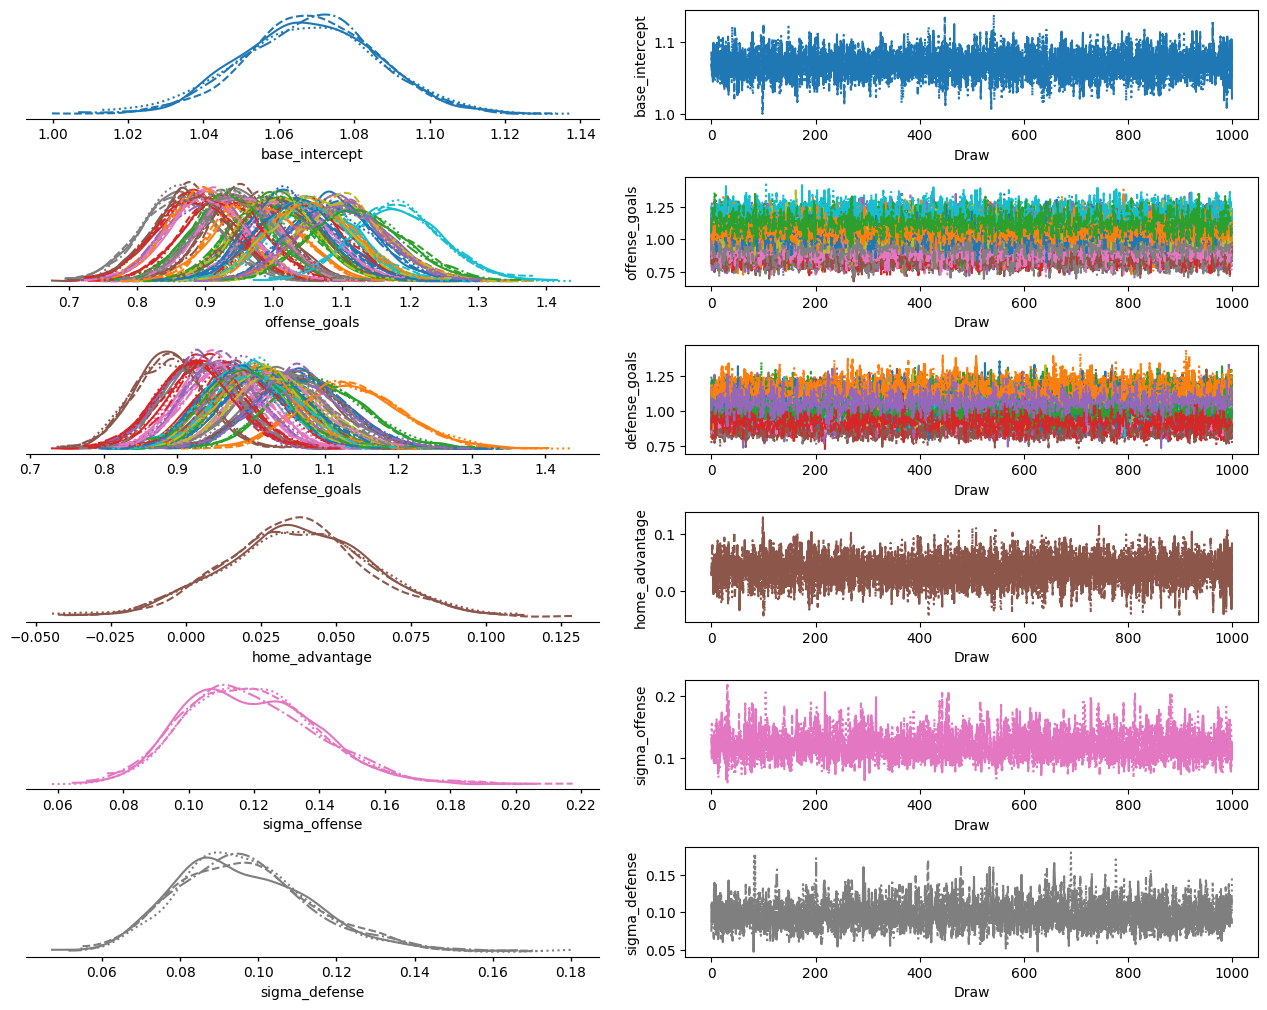

In [35]:
az.plot_trace_dist(
    trace,
    var_names=[
        "base_intercept",
        "offense_goals",
        "defense_goals",
        "home_advantage",
        # "team_home_advantage",
        "home_advantage",
        "sigma_offense",
        "sigma_defense",
    ],
)
plt.tight_layout()

In [37]:
from numpyro.infer import Predictive

predict = Predictive(model, mcmc.get_samples())

pred_key = random.key(91293881879198)
preds = predict(pred_key, test_matchups)

In [38]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


test_predictions = preds["prob_home_win"] > 0.5
full_accuracy = accuracy_score(test_home_wins, test_predictions.mean(axis=0) > 0.5)
print(f"Full (Skellam) Accuracy: {full_accuracy:.3f}")
print(preds["prob_home_win"].shape)


Full (Skellam) Accuracy: 0.578
(4000, 263)


In [ ]:
# refit on the full dataset
mcmc.run(
    random.key(98102938376),
    matchups=team_matchups,
    home_g=home_g_reg,
    away_g=away_g_reg,
    is_ot=overtimes,
    home_win=home_wins,
)

jax.effects_barrier()

/Users/mmcanear/Projects/hockey/.venv/lib/python3.14/site-packages/jax/_src/linear_util.py:212: FutureWarning: Some algorithms will automatically enumerate the discrete latent site home_ot_wins_unobserved of your model. In the future, enumerated sites need to be marked with `infer={'enumerate': 'parallel'}`.
  return self.f_transformed(*args, **kwargs)
Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]



Running chain 0:   5%|▌         | 150/3000 [00:02<00:14, 193.09it/s]


Running chain 0:  10%|█         | 300/3000 [00:02<00:07, 338.07it/s]


Running chain 0:  15%|█▌        | 450/3000 [00:03<00:05, 477.08it/s]


Running chain 0:  20%|██        | 600/3000 [00:03<00:04, 590.37it/s]


Running chain 0:  25%|██▌       | 750/3000 [00:03<00:03, 692.43it/s]


Running chain 0:  30%|███       | 900/3000 [00:03<00:02, 758.12it/s]


Running chain 0:  35%|███▌      | 1050/3000 [00:03<00:02, 791.01it/s]


Running chain 0:  40%|████

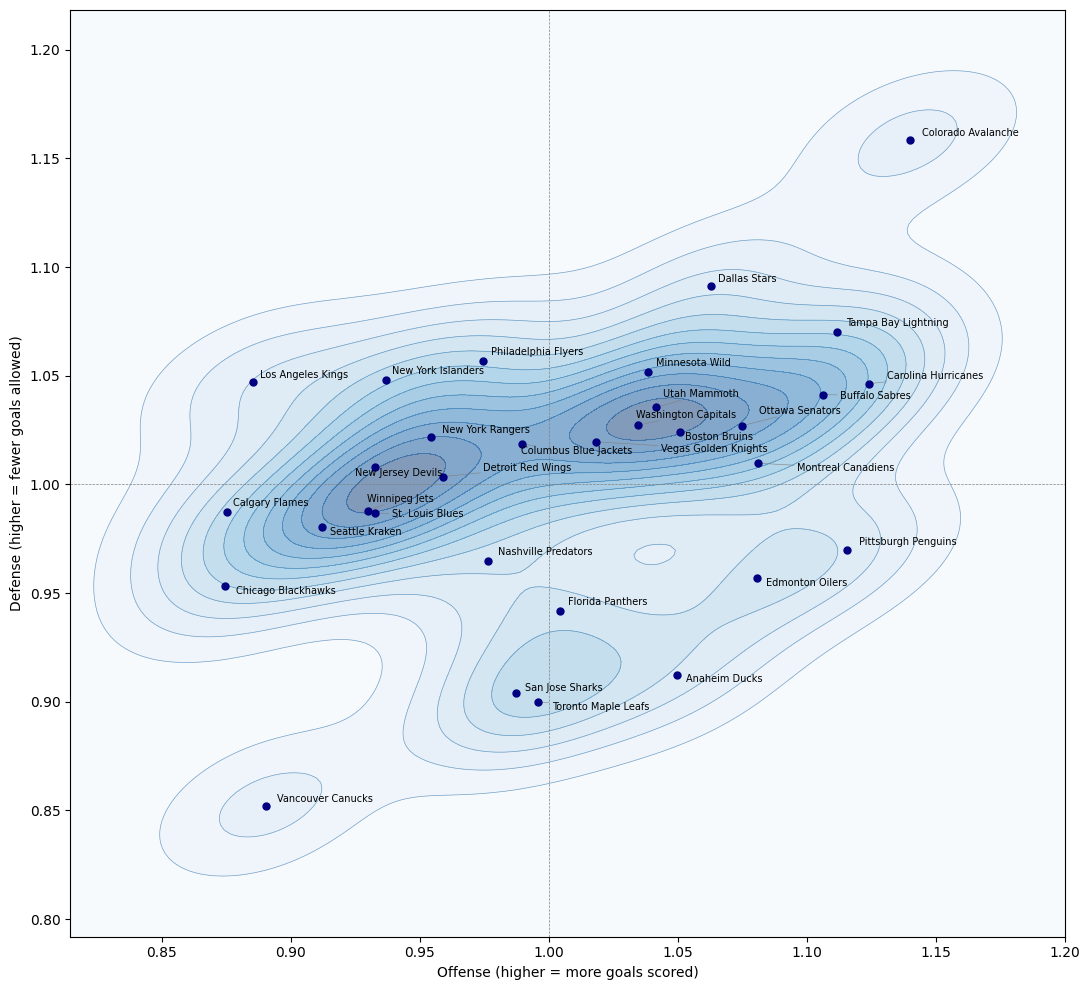

In [61]:
from scipy.stats import gaussian_kde
from adjustText import adjust_text

trace = az.from_numpyro(
    mcmc,
    coords={"team": teams},
    dims={
        "offense_goals": ["team"],
        "defense_goals": ["team"],
    },
)
predict = Predictive(model, mcmc.get_samples())

off_samples = trace.posterior["offense_goals"].values.reshape(-1, len(teams))
def_samples = trace.posterior["defense_goals"].values.reshape(-1, len(teams))
off_mean = off_samples.mean(axis=0)
def_mean = def_samples.mean(axis=0)

# KDE over team posterior means — shows the league-level distribution of ratings
kde = gaussian_kde(np.vstack([off_mean, def_mean]), bw_method=0.4)

pad = 0.06
x_grid = np.linspace(off_mean.min() - pad, off_mean.max() + pad, 200)
y_grid = np.linspace(def_mean.min() - pad, def_mean.max() + pad, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

fig, ax = plt.subplots(figsize=(11, 10))
ax.contourf(X, Y, Z, levels=12, cmap="Blues", alpha=0.5)
ax.contour(X, Y, Z, levels=12, colors="steelblue", linewidths=0.5, alpha=0.7)

ax.scatter(off_mean, def_mean, s=25, color="navy", zorder=3)

texts = [
    ax.text(x, y, team, fontsize=7)
    for team, x, y in zip(teams, off_mean, def_mean)
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4))

ax.axhline(1, color="gray", lw=0.5, ls="--")
ax.axvline(1, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Offense (higher = more goals scored)")
ax.set_ylabel("Defense (higher = fewer goals allowed)")
plt.tight_layout()

In [14]:
game_states = [(w, l) for w in range(5) for l in range(5) if w + l <= 7]
terminal_states = [t for t in game_states if 4 in t]
transitional_states = [s for s in game_states if s not in terminal_states]
game_states = transitional_states + terminal_states


def generate_matchup(home_team, away_team, teams=teams):
    home_idx, away_idx = teams.index(home_team), teams.index(away_team)
    input_idx = jnp.zeros(len(teams))
    input_idx = input_idx.at[home_idx].set(1)
    input_idx = input_idx.at[away_idx].set(-1)
    return input_idx.reshape(1, -1)


def make_transition_indices(game_states):
    from_idx, to_win_idx, to_loss_idx, terminal_idx = [], [], [], []
    for i, state in enumerate(game_states):
        if 4 in state:
            terminal_idx.append(i)
        else:
            from_idx.append(i)
            to_win_idx.append(game_states.index((state[0] + 1, state[1])))
            to_loss_idx.append(game_states.index((state[0], state[1] + 1)))
    return (
        jnp.array(from_idx),
        jnp.array(to_win_idx),
        jnp.array(to_loss_idx),
        jnp.array(terminal_idx),
    )


# Precompute once — Python loops run here, not inside JIT
from_idx, to_win_idx, to_loss_idx, terminal_idx = make_transition_indices(game_states)


@jax.jit
def construct_transition_matrix(p):
    n = len(game_states)
    mat = jnp.zeros((n, n))
    mat = mat.at[from_idx, to_win_idx].set(p)
    mat = mat.at[from_idx, to_loss_idx].set(1 - p)
    mat = mat.at[terminal_idx, terminal_idx].set(1.0)
    return mat

In [1]:
from rich.console import Console
from rich.table import Table
from rich.columns import Columns
from rich import box

console = Console()

In [62]:
def run_playoff_series(rng_key, home_team, away_team, game_states):

    home_matchup = generate_matchup(home_team, away_team)
    away_matchup = -home_matchup

    k1, k2 = random.split(rng_key, 2)
    home_goals = predict(k1, home_matchup)
    away_goals = predict(k2, away_matchup)

    home_matrices = jax.vmap(construct_transition_matrix, in_axes=(0,))(
        home_goals["prob_home_win"]
    )
    away_matrices = jax.vmap(construct_transition_matrix, in_axes=(0,))(
        1 - away_goals["prob_home_win"]
    )

    def series_outcome(hm, am):
        mats = jnp.array([hm, hm, am, am, hm, am, hm])
        v = jnp.zeros(len(game_states)).at[0].set(1.0)
        final_v, _ = jax.lax.scan(lambda v, mat: (v @ mat, None), v, mats)
        return final_v

    series_outcomes = jax.vmap(series_outcome, in_axes=(0, 0))(
        home_matrices, away_matrices
    )
    return_arr = xr.DataArray(
        series_outcomes,
        dims=["sample", "game_state"],
        coords={
            "game_state": [f"{w}-{l}" for w, l in game_states],
            "sample": np.arange(series_outcomes.shape[0]),
        },
    ).sel(game_state=[f"{w}-{l}" for w, l in game_states if 4 in (w, l)])

    return_arr.attrs["teams"] = (home_team, away_team)
    return return_arr


def conditional_wins(win_probs, a_wins, b_wins):
    reachable = [
        state.item()
        for state in win_probs.coords["game_state"]
        if int(state.item().split("-")[0]) >= a_wins and int(state.item().split("-")[1]) >= b_wins
    ]

    conditional = win_probs.sel(game_state=reachable)
    normalized = conditional / conditional.sum(axis=1)

    a_states = [s for s in reachable if s.split("-")[0] == "4"]
    b_states = [s for s in reachable if s.split("-")[1] == "4"]

    p_a_wins = float(normalized.sel(game_state=a_states).sum(axis=1).mean())
    p_b_wins = float(normalized.sel(game_state=b_states).sum(axis=1).mean())

    team_a, team_b = win_probs.attrs["teams"]
    a_win_probs = normalized.sel(game_state=a_states).mean(axis=0)
    b_win_probs = normalized.sel(game_state=b_states).mean(axis=0)

    def make_team_table(team, p_win, states, probs):
        t = Table(title=f"{team}  {p_win:.1%}", box=box.SIMPLE_HEAD)
        t.add_column("Outcome", justify="center")
        t.add_column("Prob", justify="right")
        for state, p in zip(states, probs.values):
            t.add_row(state, f"{p:.1%}")
        return t

    console.rule(f"[bold]{team_a} {a_wins} – {b_wins} {team_b}[/bold]")
    console.print(Columns([
        make_team_table(team_a, p_a_wins, a_states, a_win_probs),
        make_team_table(team_b, p_b_wins, b_states, b_win_probs),
    ]))

In [63]:
def run_series_report(series_simulation):
    a_to_states = ["4-0", "4-1", "4-2", "4-3"]
    b_to_states = ["3-4", "2-4", "1-4", "0-4"]

    team_A_win_probs = series_simulation.sel(game_state=a_to_states).mean(dim="sample")
    team_B_win_probs = series_simulation.sel(game_state=b_to_states).mean(dim="sample")

    teamA, teamB = series_simulation.attrs["teams"]

    table = Table(title=f"{teamA} vs {teamB}", box=box.ROUNDED)
    table.add_column("Team", style="bold", min_width=22)
    table.add_column("Win %", justify="right", style="bold cyan")
    table.add_column("Sweep", justify="right")
    table.add_column("5 games", justify="right")
    table.add_column("6 games", justify="right")
    table.add_column("7 games", justify="right")

    # b_to_states runs 7→sweep; reverse to align with a_to_states (sweep→7)
    b_vals = team_B_win_probs.values[::-1]

    table.add_row(teamA, f"{float(team_A_win_probs.sum()):.1%}",
                  *[f"{p:.1%}" for p in team_A_win_probs.values])
    table.add_row(teamB, f"{float(team_B_win_probs.sum()):.1%}",
                  *[f"{p:.1%}" for p in b_vals])

    console.print(table)

In [64]:
outcome = run_playoff_series(random.key(19835620), "Vegas Golden Knights", "Anaheim Ducks", game_states)
run_series_report(outcome)

                 Vegas Golden Knights vs Anaheim Ducks                  
╭────────────────────────┬───────┬───────┬─────────┬─────────┬─────────╮
│ Team                   │ Win % │ Sweep │ 5 games │ 6 games │ 7 games │
├────────────────────────┼───────┼───────┼─────────┼─────────┼─────────┤
│ Vegas Golden Knights   │ 59.5% │  9.2% │   16.7% │   17.2% │   16.6% │
│ Anaheim Ducks          │ 40.5% │  4.7% │    9.4% │   13.3% │   13.0% │
╰────────────────────────┴───────┴───────┴─────────┴─────────┴─────────╯


In [65]:
conditional_wins(outcome, 2, 3)

─────────────────── Vegas Golden Knights 2 – 3 Anaheim Ducks ───────────────────
   Vegas Golden        Anaheim Ducks   
  Knights  39.4%           60.6%       
                                       
  Outcome    Prob     Outcome    Prob  
 ─────────────────   ───────────────── 
    4-3     39.4%       2-4     30.5%  
                        3-4     30.1%  
                                       


In [66]:
tourney_outcomes = [
    run_playoff_series(k, home, away, game_states)
    for (k, home, away) in zip(
        jax.random.split(jax.random.key(10), 3),
        ["Colorado Avalanche", "Vegas Golden Knights", "Buffalo Sabres"],
        ["Minnesota Wild", "Anaheim Ducks", "Montreal Canadiens"],
    )
]

In [67]:
records = [
    conditional_wins(outcome, a, b)
    for outcome, (a, b) in zip(tourney_outcomes, [(2, 1), (2, 2), (1, 2)])
]

─────────────────── Colorado Avalanche 2 – 1 Minnesota Wild ────────────────────
Colorado Avalanche    Minnesota Wild   
       73.5%               26.5%       
                                       
  Outcome    Prob     Outcome    Prob  
 ─────────────────   ───────────────── 
    4-1     27.2%       2-4     12.8%  
    4-2     25.0%       3-4     13.7%  
    4-3     21.3%                      
                                       
─────────────────── Vegas Golden Knights 2 – 2 Anaheim Ducks ───────────────────
   Vegas Golden        Anaheim Ducks   
  Knights  56.5%           43.5%       
                                       
  Outcome    Prob     Outcome    Prob  
 ─────────────────   ───────────────── 
    4-2     28.8%       2-4     22.0%  
    4-3     27.7%       3-4     21.5%  
                                       
─────────────────── Buffalo Sabres 1 – 2 Montreal Canadiens ────────────────────
  Buffalo Sabres    Montreal Canadiens 
       47.0%               53.0%     